<a href="https://colab.research.google.com/github/durgagoutham19-hub/Suicide-Risk-Assessment-Agent/blob/main/Suicide_Risk_Assessment_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE1-BUILD ML MODEL


In [6]:
#Install&imports
import re, string, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
#Cell 2 — Upload & load the dataset
from google.colab import files

print("Please upload the 'Suicide_Detection.csv' file.")
uploaded = files.upload()

Please upload the 'Suicide_Detection.csv' file.


Saving Suicide_Detection.csv to Suicide_Detection (1).csv


In [5]:
print(df.shape)
print(df['class'].value_counts())
df.head()

(60000, 2)
class
non-suicide    30000
suicide        30000
Name: count, dtype: int64


,text,class
0,just a quick reminder bisexual isn’t 50% gay 5...,non-suicide
1,I survived an attemptI am so done with myself....,suicide
2,I have a green light Ok so everybody telling m...,non-suicide
3,Suicidal once againAfter telling myself not to...,suicide
4,Someone just upgraded our zoom Me and my group...,non-suicide


In [7]:
#Cell 3 — Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')

def clean_text(text):
    text = str(text).lower()
    text = url_pattern.sub(' ', text)
    text = html_pattern.sub(' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df['label'] = (df['class'].str.strip().str.lower() == 'suicide').astype(int)
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,just a quick reminder bisexual isn’t 50% gay 5...,quick reminder bisexual isn’t gay straight it’...,0
1,I survived an attemptI am so done with myself....,survived attempti done sucked living couldn’t ...,1
2,I have a green light Ok so everybody telling m...,green light everybody telling like pretty sure...,0
3,Suicidal once againAfter telling myself not to...,suicidal againafter telling get suicidal near ...,1
4,Someone just upgraded our zoom Me and my group...,someone upgraded zoom group friend studying zo...,0


In [8]:
#Cell 4 — Train/test split + TF-IDF
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, stratify=df['label'], random_state=RANDOM_STATE
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(X_train.shape, X_test.shape)

(48000, 20000) (12000, 20000)


In [10]:
#Cell 5 — Train & compare model
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE),
    "SVM (Linear)": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), cv=3),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, early_stopping=True,
                          random_state=RANDOM_STATE),
}

trained = {}
results = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    trained[name] = model
    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1-Score": f1, "Train Time (s)": round(train_time, 1)})
    print(f"{name:22s} | Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f} | {train_time:.1f}s")

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

Naive Bayes            | Acc 0.9128 | Prec 0.8882 | Rec 0.9445 | F1 0.9155 | 0.1s
Logistic Regression    | Acc 0.9277 | Prec 0.9382 | Rec 0.9158 | F1 0.9269 | 7.3s
Random Forest          | Acc 0.8912 | Prec 0.8870 | Rec 0.8965 | F1 0.8917 | 370.3s
XGBoost                | Acc 0.9113 | Prec 0.9310 | Rec 0.8883 | F1 0.9092 | 321.8s
SVM (Linear)           | Acc 0.9319 | Prec 0.9386 | Rec 0.9243 | F1 0.9314 | 2.4s
MLP                    | Acc 0.9320 | Prec 0.9355 | Rec 0.9280 | F1 0.9317 | 241.8s


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,MLP,0.932000,0.935484,0.928000,0.931727,241.8
1,SVM (Linear),0.931917,0.938568,0.924333,0.931396,2.4
2,Logistic Regression,0.927750,0.938194,0.915833,0.926879,7.3
3,Naive Bayes,0.912833,0.888245,0.944500,0.915509,0.1
4,XGBoost,0.911250,0.931004,0.888333,0.909168,321.8
5,Random Forest,0.891167,0.887038,0.896500,0.891744,370.3


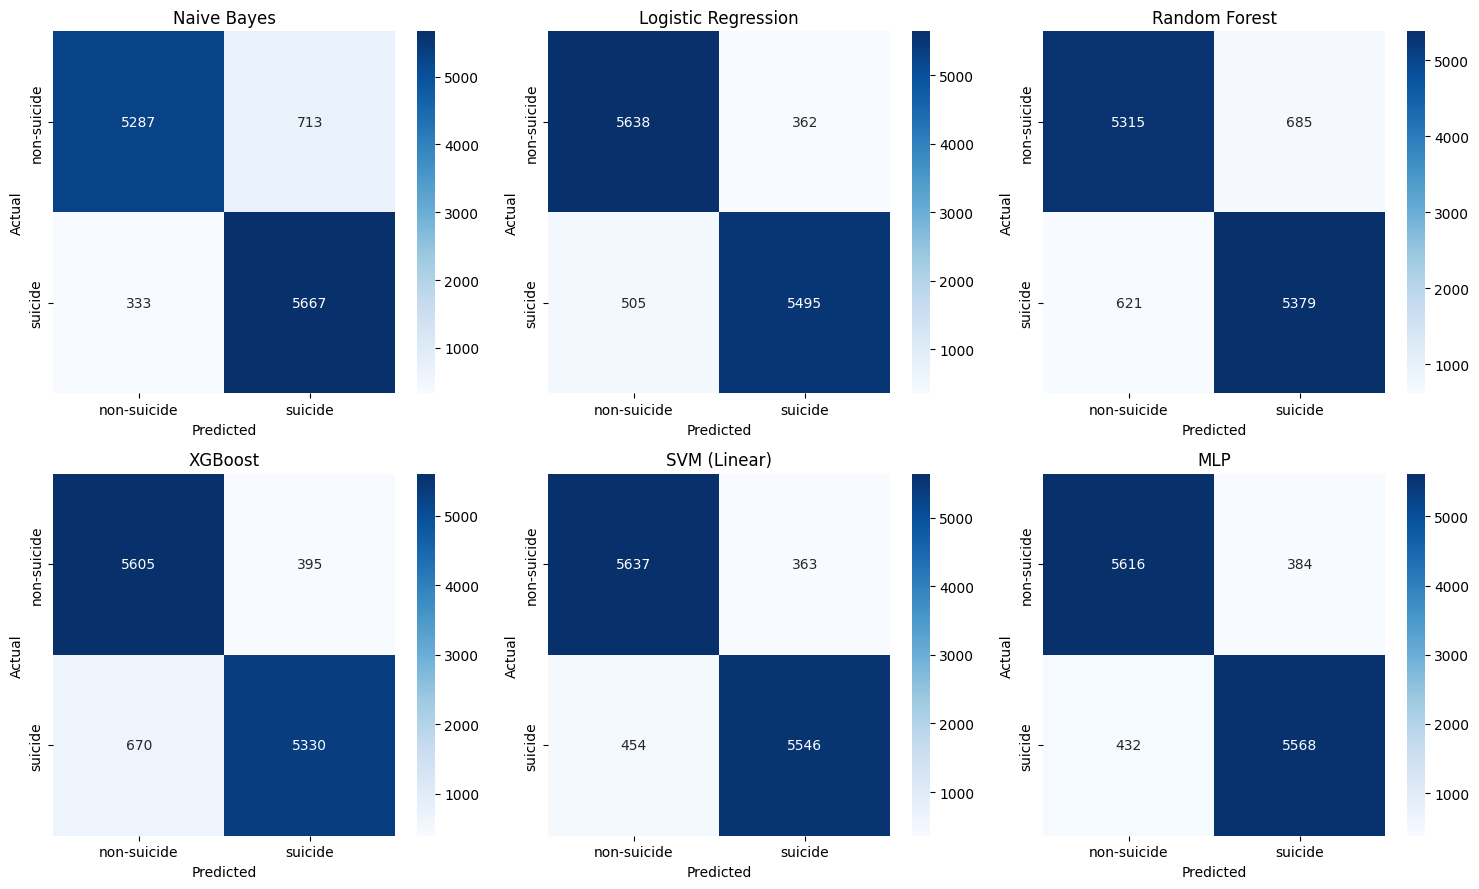

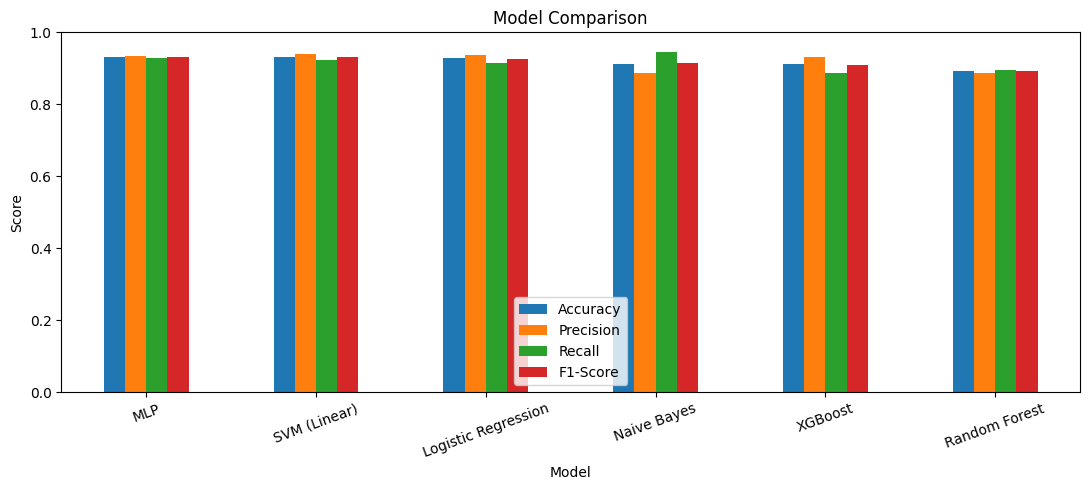

              precision    recall  f1-score   support

 non-suicide       0.93      0.94      0.93      6000
     suicide       0.94      0.93      0.93      6000

    accuracy                           0.93     12000
   macro avg       0.93      0.93      0.93     12000
weighted avg       0.93      0.93      0.93     12000



In [14]:
#WCell 6 — Confusion matrices & comparison chart
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, model) in zip(axes.flatten(), trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['non-suicide', 'suicide'], yticklabels=['non-suicide', 'suicide'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(11, 5), ylim=(0, 1)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(classification_report(y_test, trained[results_df.iloc[0]['Model']].predict(X_test),
                             target_names=['non-suicide', 'suicide']))

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,MLP,0.932000,0.935484,0.928000,0.931727,241.800000
1,SVM (Linear),0.931917,0.938568,0.924333,0.931396,2.400000
2,Logistic Regression,0.927750,0.938194,0.915833,0.926879,7.300000
3,Naive Bayes,0.912833,0.888245,0.944500,0.915509,0.100000
4,XGBoost,0.911250,0.931004,0.888333,0.909168,321.800000
5,Random Forest,0.891167,0.887038,0.896500,0.891744,370.300000


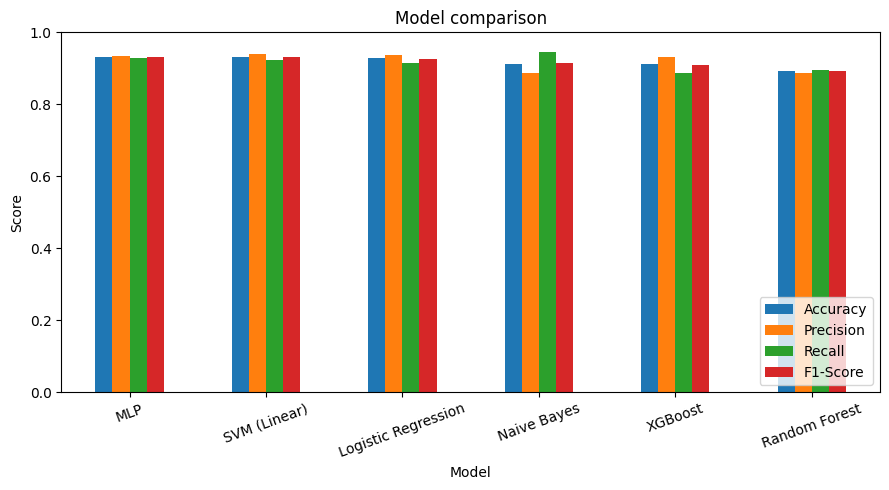

Best model by F1: MLP


In [17]:
display(results_df.style.background_gradient(cmap='Greens'))

results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(9, 5), ylim=(0, 1)
)
plt.title('Model comparison')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print('Best model by F1:', best_model_name)

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]

joblib.dump(best_model, 'best_risk_model.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print(f"Saved '{best_model_name}' as best_risk_model.joblib (+ tfidf_vectorizer.joblib)")

Saved 'MLP' as best_risk_model.joblib (+ tfidf_vectorizer.joblib)


PHASE2-BUILD AI AGENT

In [19]:
LOG_PATH = "risk_assessment_log.csv"
CRISIS_LINE = "US: 988 (call/text) | Intl directory: https://www.iasp.info/resources/Crisis_Centres/"

def risk_tier(prob):
    if prob >= 0.75:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

def recommendation(tier):
    if tier == "High":
        return ("Strong linguistic risk indicators detected. Flag for immediate human review "
                "by a counselor/crisis-response team. Do not rely on automated response alone.")
    elif tier == "Medium":
        return ("Some risk indicators present. Recommend follow-up check-in from a trained "
                "moderator/counselor and continued monitoring.")
    else:
        return "No strong risk indicators detected in this text. Routine monitoring only."

def _log_columns():
    return ["timestamp", "user_id", "text_snippet", "risk_probability", "risk_tier", "alert_generated"]

def _append_log(record):
    row = pd.DataFrame([record], columns=_log_columns())
    try:
        existing = pd.read_csv(LOG_PATH)
        pd.concat([existing, row], ignore_index=True).to_csv(LOG_PATH, index=False)
    except FileNotFoundError:
        row.to_csv(LOG_PATH, index=False)

In [20]:
class SuicideRiskAgent:
    def __init__(self, model, vectorizer):
        self.model = model
        self.vectorizer = vectorizer

    def _predict_proba(self, cleaned_text):
        X = self.vectorizer.transform([cleaned_text])
        if hasattr(self.model, "predict_proba"):
            return float(self.model.predict_proba(X)[0][1])
        return float(self.model.predict(X)[0])

    def analyze(self, text, user_id="anonymous", log=True):
        cleaned = clean_text(text)
        prob = self._predict_proba(cleaned)
        tier = risk_tier(prob)
        alert = tier in ("Medium", "High")

        result = {
            "user_id": user_id, "text": text,
            "risk_probability": round(prob, 4),
            "risk_tier": tier, "alert_generated": alert,
        }

        if log:
            _append_log({
                "timestamp": datetime.utcnow().isoformat(),
                "user_id": user_id,
                "text_snippet": text[:120],
                "risk_probability": result["risk_probability"],
                "risk_tier": tier,
                "alert_generated": alert,
            })
        return result

    def report(self, text, user_id="anonymous", log=True):
        res = self.analyze(text, user_id=user_id, log=log)
        print("=" * 50)
        print("SUICIDE RISK ASSESSMENT REPORT")
        print("=" * 50)
        print("Inputs:")
        print(f"  - User ID: {res['user_id']}")
        print(f"  - Timestamp: {datetime.utcnow().isoformat()}")
        print(f"  - Text: \"{res['text'][:100]}{'...' if len(res['text']) > 100 else ''}\"")
        print()
        print("Predictions:")
        print(f"  - Risk Probability: {res['risk_probability']*100:.2f}%")
        print(f"  - Risk Tier: {res['risk_tier']}")
        print(f"  - Alert Generated: {'YES' if res['alert_generated'] else 'No'}")
        print()
        print("Recommendation:")
        print(f"  {recommendation(res['risk_tier'])}")
        if res['alert_generated']:
            print()
            print(f"  Crisis resources: {CRISIS_LINE}")
        print("=" * 50)
        return res

agent = SuicideRiskAgent(best_model, tfidf)

In [21]:
agent.report(
    "I feel so alone lately, nothing seems to matter anymore and I don't see the point in continuing.",
    user_id="user_042"
)

SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: user_042
  - Timestamp: 2026-08-12T10:15:02.785959
  - Text: "I feel so alone lately, nothing seems to matter anymore and I don't see the point in continuing."

Predictions:
  - Risk Probability: 99.15%
  - Risk Tier: High
  - Alert Generated: YES

Recommendation:
  Strong linguistic risk indicators detected. Flag for immediate human review by a counselor/crisis-response team. Do not rely on automated response alone.

  Crisis resources: US: 988 (call/text) | Intl directory: https://www.iasp.info/resources/Crisis_Centres/


/tmp/ipykernel_458/1169346136.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_458/1169346136.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"  - Timestamp: {datetime.utcnow().isoformat()}")


{'user_id': 'user_042',
 'text': "I feel so alone lately, nothing seems to matter anymore and I don't see the point in continuing.",
 'risk_probability': 0.9915,
 'risk_tier': 'High',
 'alert_generated': True}

In [22]:
sample_texts = [
    "I got promoted at work today and I'm celebrating with friends tonight!",
    "Just finished a great workout, feeling energized for the week ahead.",
    "i need helpjust help me im crying so hard",
]
for t in sample_texts:
    agent.report(t, user_id="demo_user")
    print()

records = pd.read_csv(LOG_PATH)
records

SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: demo_user
  - Timestamp: 2026-08-12T10:15:12.586363
  - Text: "I got promoted at work today and I'm celebrating with friends tonight!"

Predictions:
  - Risk Probability: 42.23%
  - Risk Tier: Medium
  - Alert Generated: YES

Recommendation:
  Some risk indicators present. Recommend follow-up check-in from a trained moderator/counselor and continued monitoring.

  Crisis resources: US: 988 (call/text) | Intl directory: https://www.iasp.info/resources/Crisis_Centres/

SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: demo_user
  - Timestamp: 2026-08-12T10:15:12.598388
  - Text: "Just finished a great workout, feeling energized for the week ahead."

Predictions:
  - Risk Probability: 2.64%
  - Risk Tier: Low
  - Alert Generated: No

Recommendation:
  No strong risk indicators detected in this text. Routine monitoring only.

SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: demo_user
  - Timestamp: 2026-08-12T10:15:12.606270
  - Text

/tmp/ipykernel_458/1169346136.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_458/1169346136.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"  - Timestamp: {datetime.utcnow().isoformat()}")
/tmp/ipykernel_458/1169346136.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_458/1169346136.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a 

,timestamp,user_id,text_snippet,risk_probability,risk_tier,alert_generated
0,2026-08-12T10:15:02.750611,user_042,"I feel so alone lately, nothing seems to matte...",0.9915,High,True
1,2026-08-12T10:15:12.578730,demo_user,I got promoted at work today and I'm celebrati...,0.4223,Medium,True
2,2026-08-12T10:15:12.589178,demo_user,"Just finished a great workout, feeling energiz...",0.0264,Low,False
3,2026-08-12T10:15:12.600658,demo_user,i need helpjust help me im crying so hard,0.6804,Medium,True


In [23]:
user_text = input("Enter the text to assess: ")
user_id = input("Enter user ID (or press Enter for 'anonymous'): ") or "anonymous"

agent.report(user_text, user_id=user_id)

Enter the text to assess: students
Enter user ID (or press Enter for 'anonymous'): 407
SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: 407
  - Timestamp: 2026-08-12T10:18:54.776723
  - Text: "students"

Predictions:
  - Risk Probability: 4.08%
  - Risk Tier: Low
  - Alert Generated: No

Recommendation:
  No strong risk indicators detected in this text. Routine monitoring only.


/tmp/ipykernel_458/1169346136.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_458/1169346136.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"  - Timestamp: {datetime.utcnow().isoformat()}")


{'user_id': '407',
 'text': 'students',
 'risk_probability': 0.0408,
 'risk_tier': 'Low',
 'alert_generated': False}

In [60]:
#@title Suicide Risk Assessment { run: "auto" }
User_ID = "user_069" #@param {type:"string"}
Text_to_Assess = "breakup,loverfailure,my lover is reject mee " #@param {type:"string"}

agent.report(Text_to_Assess, user_id=User_ID)

SUICIDE RISK ASSESSMENT REPORT
Inputs:
  - User ID: user_069
  - Timestamp: 2026-08-12T10:21:52.409408
  - Text: "breakup,loverfailure,my lover is reject mee "

Predictions:
  - Risk Probability: 12.49%
  - Risk Tier: Low
  - Alert Generated: No

Recommendation:
  No strong risk indicators detected in this text. Routine monitoring only.


/tmp/ipykernel_458/1169346136.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_458/1169346136.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"  - Timestamp: {datetime.utcnow().isoformat()}")


{'user_id': 'user_069',
 'text': 'breakup,loverfailure,my lover is reject mee ',
 'risk_probability': 0.1249,
 'risk_tier': 'Low',
 'alert_generated': False}

In [38]:
while True:
    user_text = input("\nEnter text to assess (or type 'exit' to stop): ")
    if user_text.strip().lower() == "exit":
        break
    user_id = input("User ID (Enter for 'anonymous'): ") or "anonymous"
    agent.report(user_text, user_id=user_id)


Enter text to assess (or type 'exit' to stop): exit
